## ANALYSE EXPLORATOIRE

---

### ANALYSE DE LA FORME (STRUCTURE DES DONNEES)

- `Dimensions du jeu de données`: 130 333 lignes et 15 colonnes
- `Types des données`: Aucun type à modifier, tous les types (object, float64, int64) sont corrects.
- `Valeurs manquantes`: Les colonnes `valeur_neuve` et `valeur_venale` ont environ 84% de valeurs manquantes. La colonne `tauxpart` a 96% de valeurs manquantes. C'est problématique et nous allons probablement supprimer ces colonnes.

---

### ANALYSE STATISTIQUE ET TECHNIQUE

### Statistiques descriptive
- `Variable cible`: Distribution très très asymétrique, nous pose plein de contraintes pour la modélisation.
- `Variables quantitatives`: Les distributions sont très **asymétriques** et **irrégulières**.
- `Variables qualitatives`: On observe pr variable, des modalités qui ont de très fortes cardinalité tandis que d'autre non. Exemple: Parmi les catégories mères de voiture, la catégorie `Tourisme (VP)` est largement dominante avec 40000 occurrences tandis que les autres (`2/3 Roues`, `Taxis`, `Autocars/Bus`) viennent avec maxi 5000 occurences. Ce qu'on peut également remarquer dans les variables `segment`, `type_vehicule`, `typepermis`. D'ailleurs, il est possible qu'il existe une éventuelle corrélation entre ces variables car elles regroupent les véhicules en groupes selon quelques caractéristiques.

### Analyses bivariées

- `Couples (quantitatifs) de caractéristiques de garanties automobiles`: En conclusion, il n'ya pas de relations entre ces facteurs, au sens bivarié.

- `Couples (qualitatifs) de caractéristiques de garanties automobiles`: En conclusion, il existe une liaison statistiquement significative entre tous les couples de caractéristiques qualitatives. 

- `Couples (qualitatif vs quantitatif) de caractéristiques de garanties automobiles`: En conclusion, on observe une liaison statistiquement significative entre les caractéristiques quantitatifs de la garantie d'un véhicule et les caractéristiques qualitatives.

### Analyse multivariée
- `Facteur d'inflation de la variance - Variance Inflation Factor (VIF)`:
On remarque que certaines variables / modalités ont un VIF > 5. Ce qui suggère que leur information est contenue dans les autres variables. Du coup une solution serait:
    - Soit d'utiliser une régularisation pour les modèles paramétriques (Ridge, LASSO)
    - Soit d'utiliser des modèles non paramétriques qui ne sont pas sensibles à la multicolinearite (RandomForest, XGBoost) etc... 

In [1]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Chemins d'acces
notebooks_path = os.getcwd()
project_path = os.path.dirname(notebooks_path)

data_path = os.path.join(project_path, 'Data', 'DonneesPreparees', 'dataset_final.csv')
data_path

'c:\\Users\\DELL\\Documents\\VEMV\\business\\work\\ProjetPolytech\\EstimationPrimesAssuranceAutomobile_v2\\Data\\DonneesPreparees\\dataset_final.csv'

In [3]:
# Chargement des données
df = pd.read_csv(data_path)
df.head()

,age_vehicule_annees,categorie_mère,contrat_id,cout_total_sinistres,duree_garantie_jours,garantie,marque,modèle,nb_sinistres,places,puissance,segment,type_vehicule,typeinter,typepermis,valeur_neuve,valeur_venale,y_cible,ville
0,0.982888,Flotte pro,20230301_20240229_1001-1120000299,0.0,365,Dommages,JAC,HFC 4251 KR1,0.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,1116000,YAOUNDE
1,0.982888,Flotte pro,20230301_20240229_1001-1120000299,0.0,365,Incendie,JAC,HFC 4251 KR1,0.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,51480,YAOUNDE
2,0.982888,Flotte pro,20230301_20240229_1001-1120000299,0.0,365,Dommages,JAC,HFC 4251 KR1,0.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,1116000,YAOUNDE
3,0.982888,Flotte pro,20230301_20240229_1001-1120000299,0.0,365,Incendie,JAC,HFC 4251 KR1,0.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,51480,YAOUNDE
4,0.982888,Flotte pro,20230301_20240229_1001-1120000299,11687092.0,365,Dommages,JAC,HFC 4251 KR1,1.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,1116000,YAOUNDE


## 1. Analyse de la forme (structure) des données 

In [4]:
# colonnes 
df.columns

Index(['age_vehicule_annees', 'categorie_mère', 'contrat_id',
       'cout_total_sinistres', 'duree_garantie_jours', 'garantie', 'marque',
       'modèle', 'nb_sinistres', 'places', 'puissance', 'segment',
       'type_vehicule', 'typeinter', 'typepermis', 'valeur_neuve',
       'valeur_venale', 'y_cible', 'ville'],
      dtype='object')

In [5]:
# Dimensions du jeu de données
df.shape

(5065, 19)

In [6]:
# Types de donnees
df.dtypes

age_vehicule_annees     float64
categorie_mère           object
contrat_id               object
cout_total_sinistres    float64
duree_garantie_jours      int64
garantie                 object
marque                   object
modèle                   object
nb_sinistres            float64
places                  float64
puissance               float64
segment                  object
type_vehicule            object
typeinter                object
typepermis               object
valeur_neuve            float64
valeur_venale           float64
y_cible                   int64
ville                    object
dtype: object

In [7]:
df.columns

Index(['age_vehicule_annees', 'categorie_mère', 'contrat_id',
       'cout_total_sinistres', 'duree_garantie_jours', 'garantie', 'marque',
       'modèle', 'nb_sinistres', 'places', 'puissance', 'segment',
       'type_vehicule', 'typeinter', 'typepermis', 'valeur_neuve',
       'valeur_venale', 'y_cible', 'ville'],
      dtype='object')

In [8]:
# Convertion des numeriques en float
num_cols = ['age_vehicule_annees', 'duree_garantie_jours', 'places', 'puissance', 'valeur_neuve', 'valeur_venale', 'y_cible']

for col in num_cols:
    print(f"{col}")
    df[col] = df[col].astype(float)

df.dtypes

age_vehicule_annees
duree_garantie_jours
places
puissance
valeur_neuve
valeur_venale
y_cible


age_vehicule_annees     float64
categorie_mère           object
contrat_id               object
cout_total_sinistres    float64
duree_garantie_jours    float64
garantie                 object
marque                   object
modèle                   object
nb_sinistres            float64
places                  float64
puissance               float64
segment                  object
type_vehicule            object
typeinter                object
typepermis               object
valeur_neuve            float64
valeur_venale           float64
y_cible                 float64
ville                    object
dtype: object

In [9]:
# Checking des valeurs manquantes
df.isna().sum()

age_vehicule_annees       4
categorie_mère            0
contrat_id                0
cout_total_sinistres      0
duree_garantie_jours      0
garantie                  0
marque                    0
modèle                    0
nb_sinistres              0
places                   52
puissance                 4
segment                   0
type_vehicule             0
typeinter                 0
typepermis              161
valeur_neuve            123
valeur_venale            82
y_cible                   0
ville                     0
dtype: int64

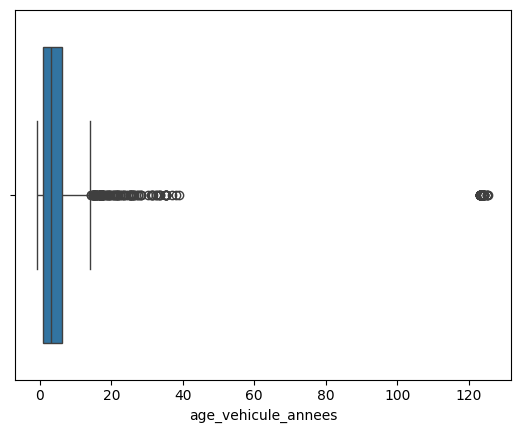

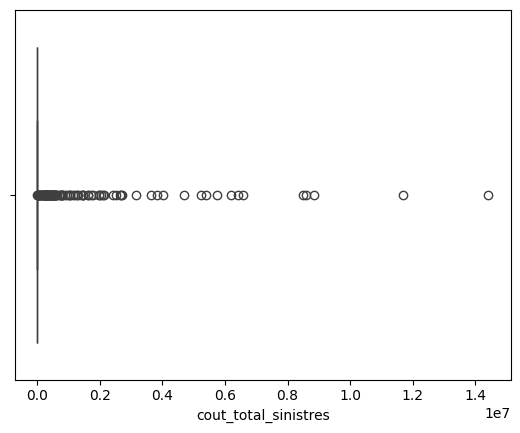

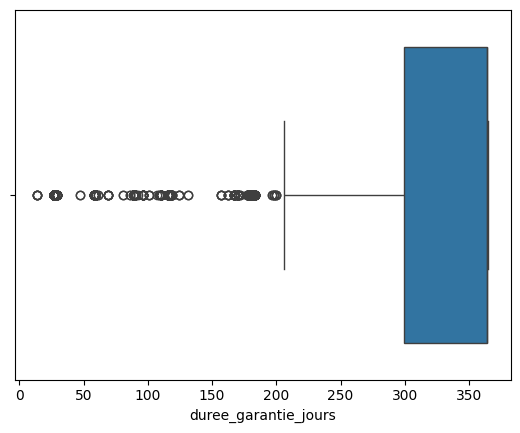

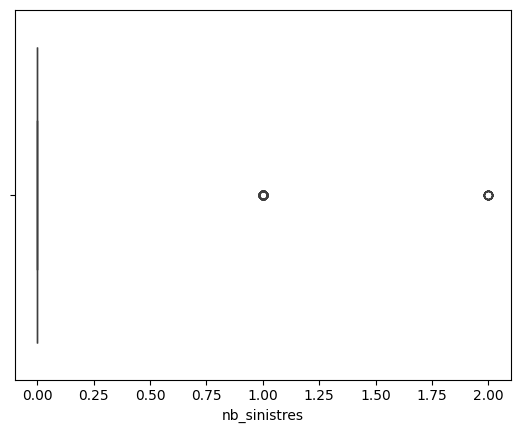

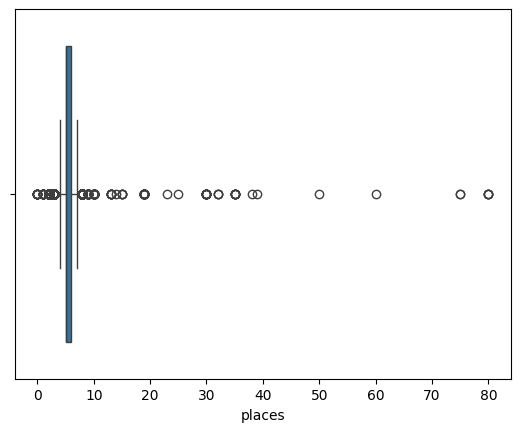

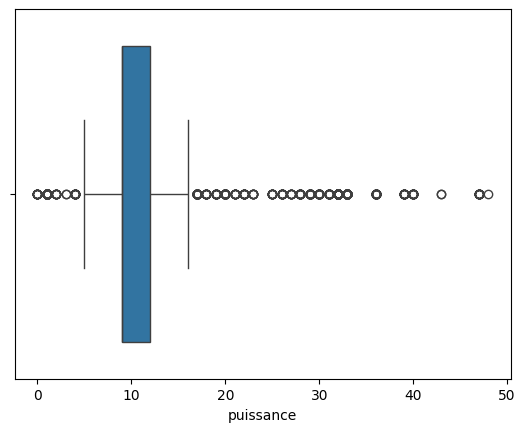

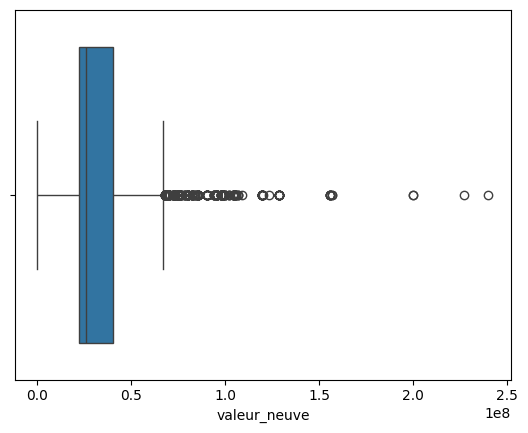

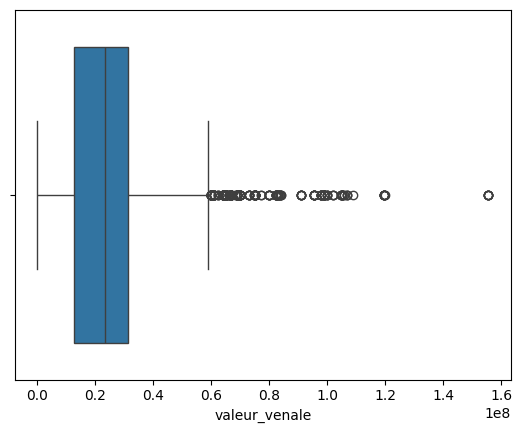

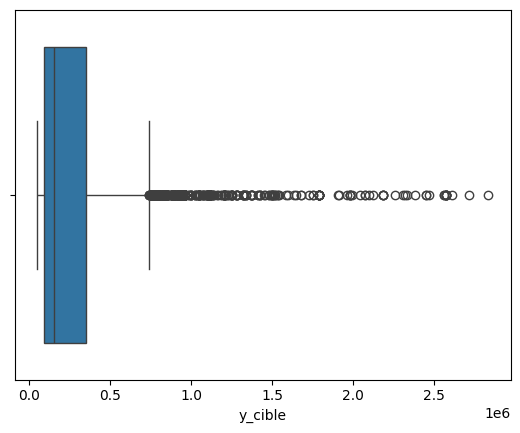

In [10]:
# Checking des outliers
quant_cols = [c for c in df.select_dtypes(include='number').columns if c != 'y_cible']

for col in quant_cols + ['y_cible']:
    plt.figure()
    sns.boxplot(data=df, x=df[col])
    plt.show()

# 2. Analyse statistique et technique des données

---

## 2.1 Statistques descriptives

QUESTION CENTRALE DE L'ANALYSE: 
**Est ce que les caractéristiques d'une garantie automobile sont également réparties entre les clients ??**

In [11]:
# Description globale
round(df.describe(), 2)

,age_vehicule_annees,cout_total_sinistres,duree_garantie_jours,nb_sinistres,places,puissance,valeur_neuve,valeur_venale,y_cible
count,5061.00,5065.00,5065.00,5065.00,5013.00,5061.00,4.942000e+03,4.983000e+03,5065.00
mean,5.43,34505.22,301.33,0.02,5.42,12.44,3.285353e+07,2.587598e+07,276316.19
std,11.06,432295.75,114.89,0.17,3.90,8.13,2.106223e+07,1.934361e+07,320767.63
min,-0.68,0.00,14.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,50000.00
25%,1.00,0.00,299.00,0.00,5.00,9.00,2.190000e+07,1.247050e+07,89839.00
50%,3.00,0.00,364.00,0.00,5.00,9.00,2.600000e+07,2.348008e+07,153403.00
75%,6.29,0.00,364.00,0.00,6.00,12.00,4.000000e+07,3.120000e+07,350000.00
max,125.49,14419750.00,365.00,2.00,80.00,48.00,2.399733e+08,1.555354e+08,2835000.00


In [12]:
# Style seaborn 
sns.set_style('whitegrid')

Text(0.5, 1.0, "Distribution des primes d'assurances")

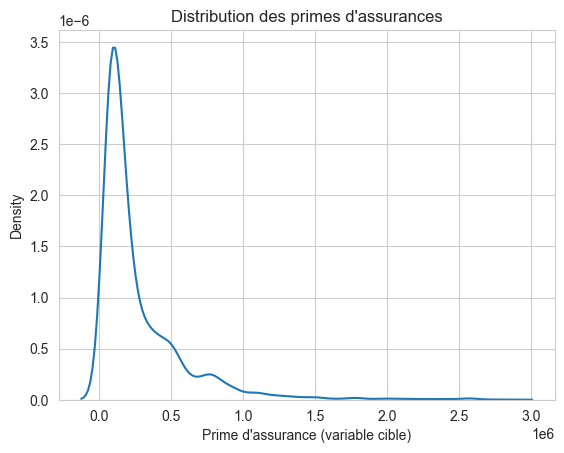

In [13]:
# Visualisation de la distribution des primes d'assurance
plt.figure()
sns.kdeplot(data=df, x= df['y_cible'])
plt.xlabel("Prime d'assurance (variable cible)")
plt.title("Distribution des primes d'assurances")

In [14]:
# Statistiques pour décrire la prime d'assurance
stats_y = {
    "Prime minimale": float(df['y_cible'].min()),
    "Premier quartile des primes": float(df['y_cible'].quantile(0.25)),
    "Mediane des primes":  float(df['y_cible'].quantile(0.5)),
    "Moyenne des primes": float(df['y_cible'].mean()),
    "Troisième quartile des primes": float(df['y_cible'].quantile(0.75)),
    "Prime maximale": float(df['y_cible'].max()),
    "Asymétrie de la distribution des primes": float(df['y_cible'].skew()),
    "Applatissement de la distribution des primes": float(df['y_cible'].kurt())
}

display(stats_y)

{'Prime minimale': 50000.0,
 'Premier quartile des primes': 89839.0,
 'Mediane des primes': 153403.0,
 'Moyenne des primes': 276316.1915103652,
 'Troisième quartile des primes': 350000.0,
 'Prime maximale': 2835000.0,
 'Asymétrie de la distribution des primes': 3.1161817068551865,
 'Applatissement de la distribution des primes': 13.618509095763777}

In [16]:
# Nombre de contrats
display(df['contrat_id'].nunique()) 

# Nombre de garanties
display(df.shape[0])

643

5065

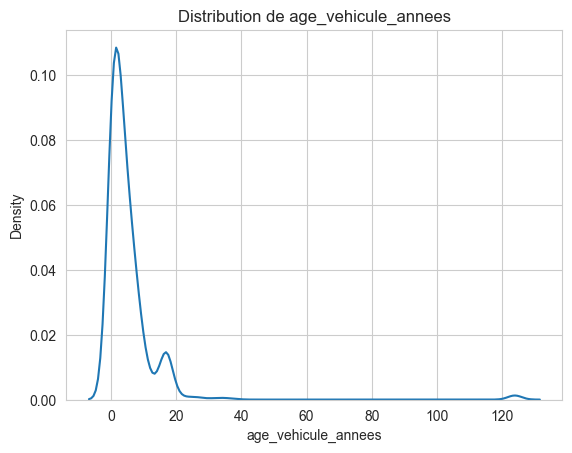

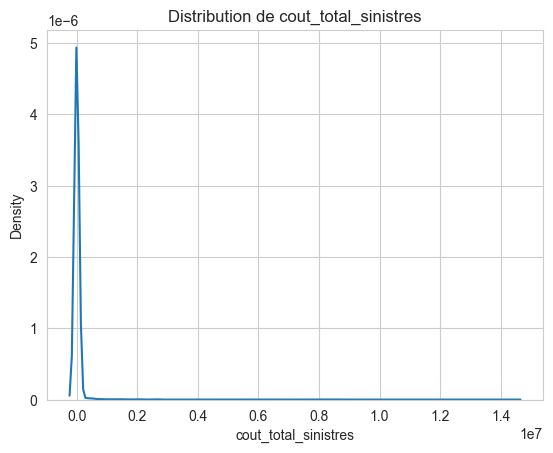

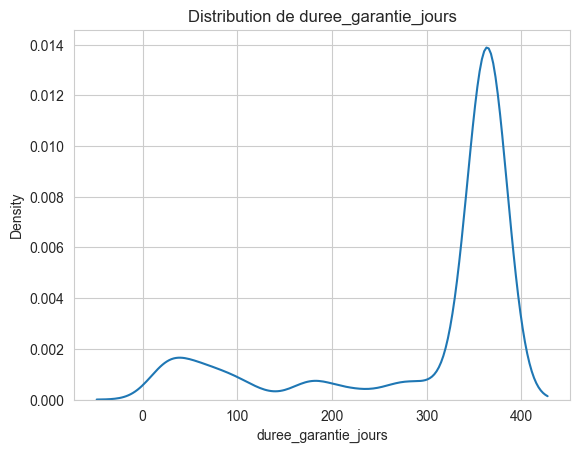

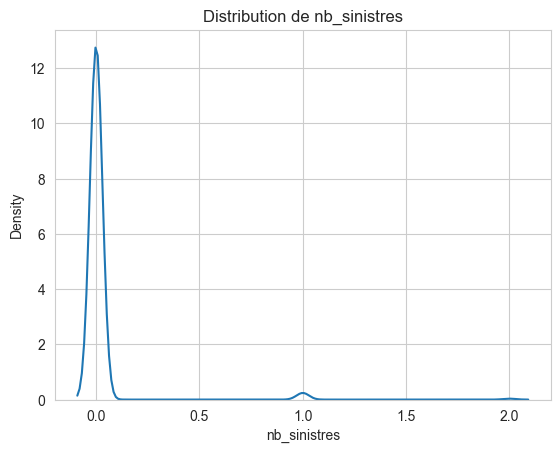

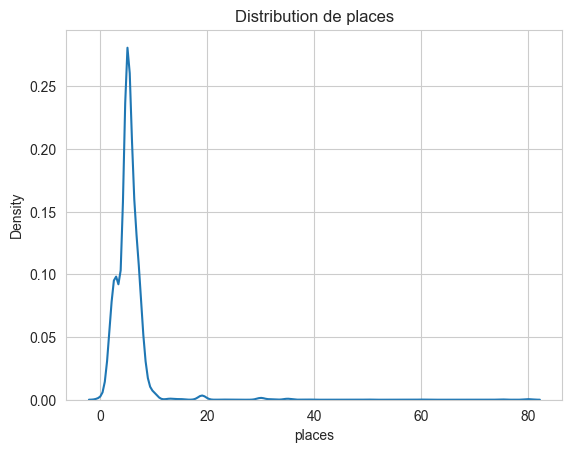

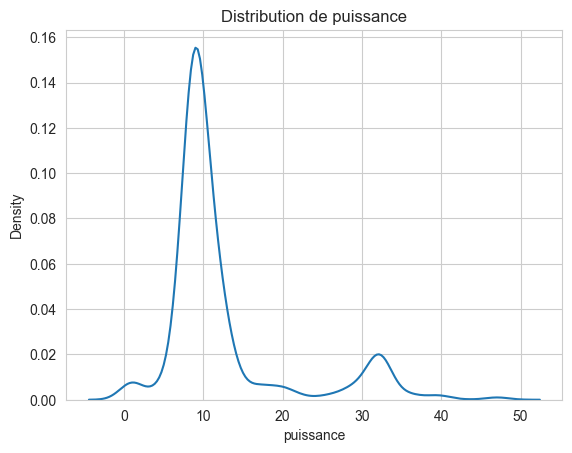

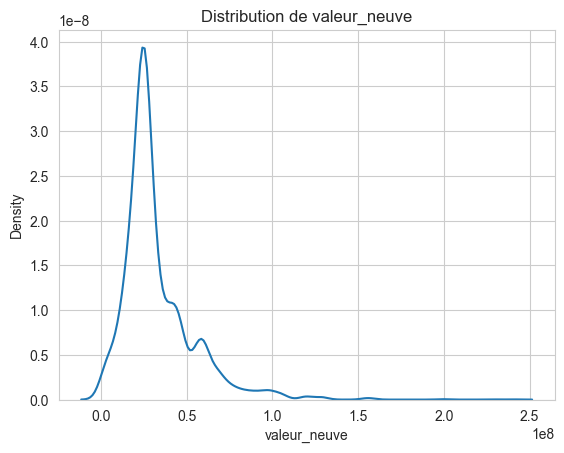

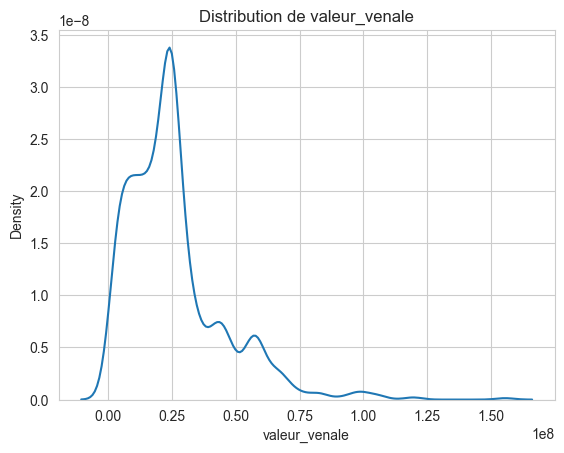

In [17]:
# Visualisation des caractéristiques de garantie quantitatives
for col in quant_cols:
    plt.figure()
    sns.kdeplot(data=df, x = df[col])
    plt.title(f"Distribution de {col}")
    plt.show()

In [18]:
# Caractéristiques de garantie qualitatives
qual_cols = [c for c in df.select_dtypes(include='object').columns if c != 'Contrat_id']
qual_cols

['categorie_mère',
 'contrat_id',
 'garantie',
 'marque',
 'modèle',
 'segment',
 'type_vehicule',
 'typeinter',
 'typepermis',
 'ville']

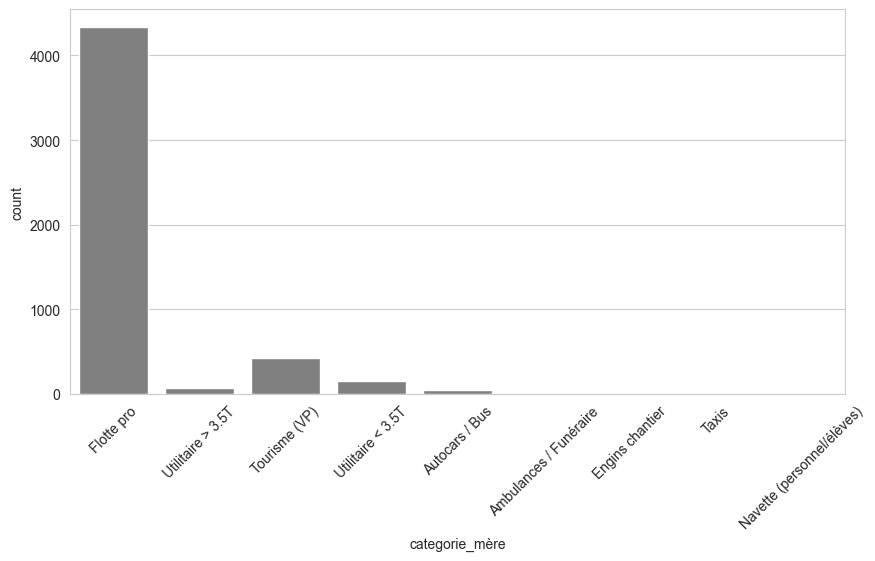

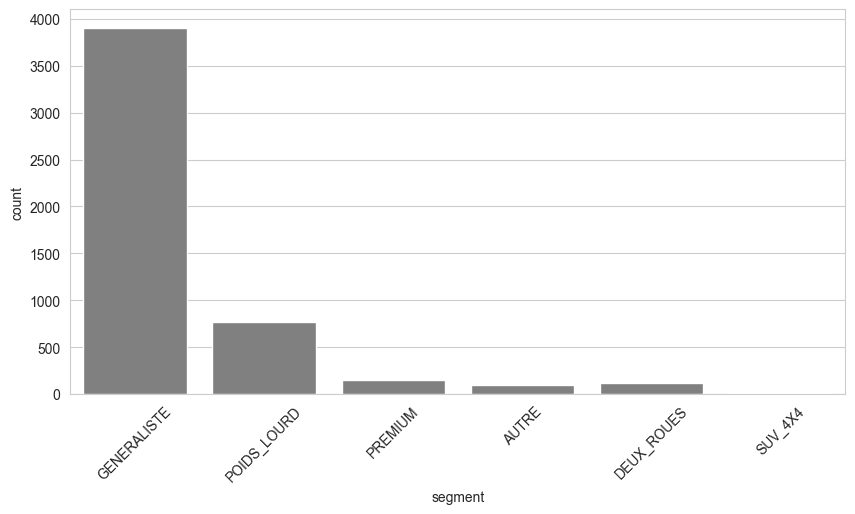

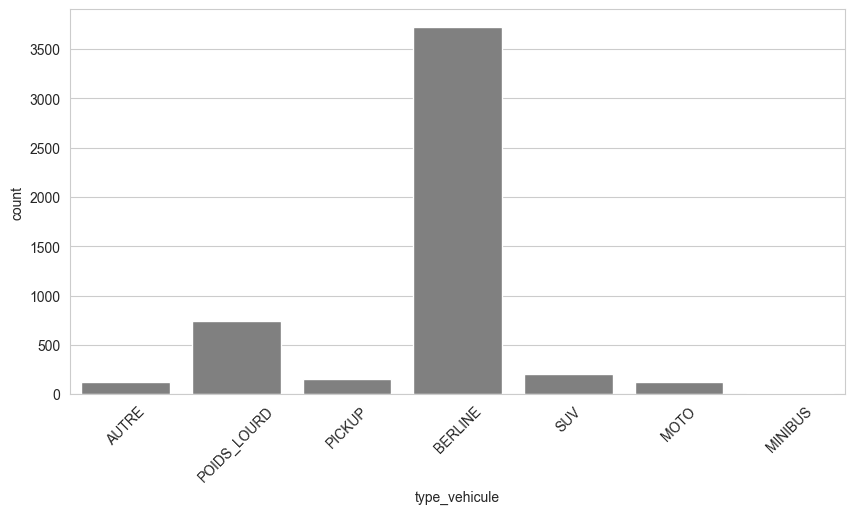

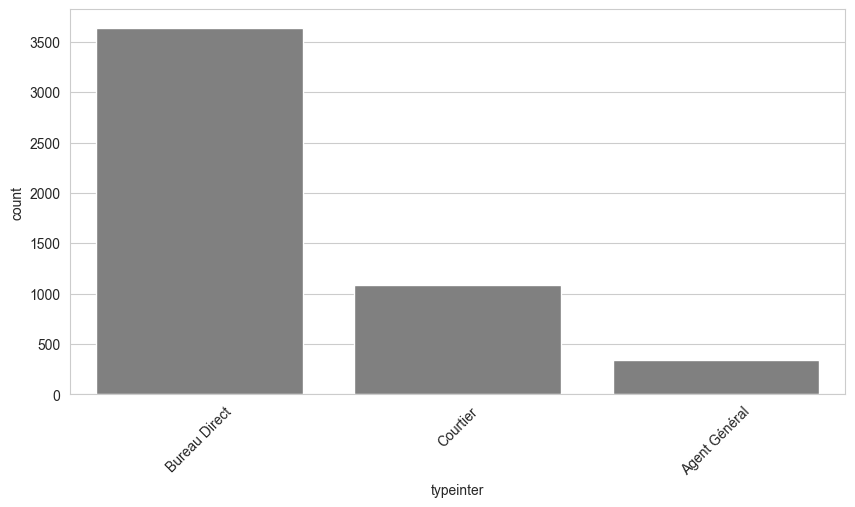

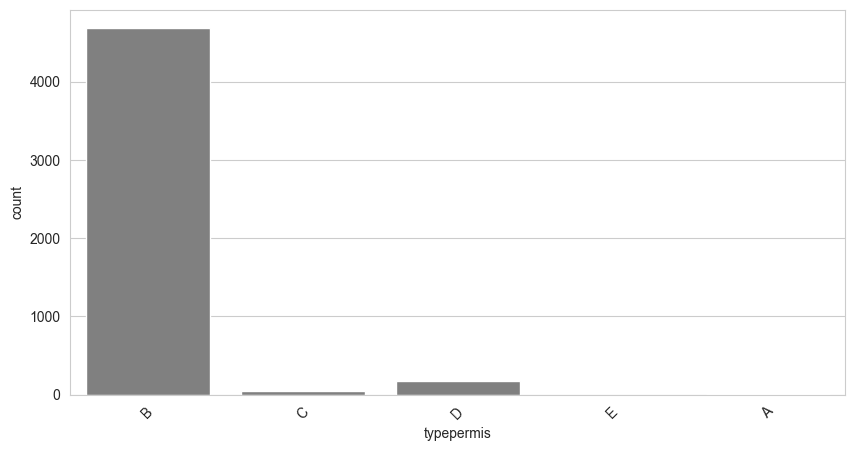

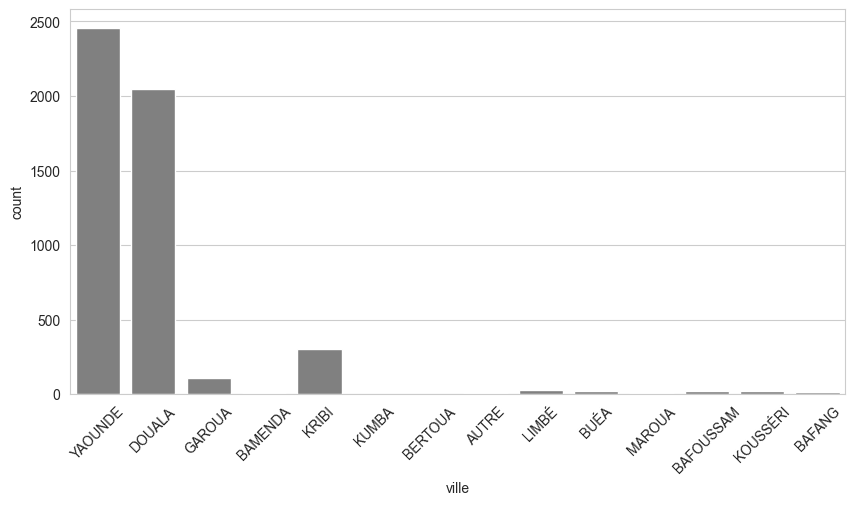

In [19]:
# Visuels 

# Caractéristiques de garantie qualitatives
qual_cols = [c for c in df.select_dtypes(include='object').columns]
for col in qual_cols:
    if df[col].nunique() < 15:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=df[col], color='grey')
        plt.xticks(rotation=45)
        plt.show()

## 2.2 Analyses bivariées

### 2.2.1 Relations entre les caractéristiques de garantie automobile quantitatives

In [20]:
display(quant_cols)
# On supprime d'abord car elles ont trop de valeurs manquantes
quant_cols = [col for col in quant_cols if col not in ['valeur_neuve', 'valeur_venale']]
display(quant_cols)

['age_vehicule_annees',
 'cout_total_sinistres',
 'duree_garantie_jours',
 'nb_sinistres',
 'places',
 'puissance',
 'valeur_neuve',
 'valeur_venale']

['age_vehicule_annees',
 'cout_total_sinistres',
 'duree_garantie_jours',
 'nb_sinistres',
 'places',
 'puissance']

Text(0.5, 1.0, "Lien entre l'age du véhicule et la durée de la garantie")

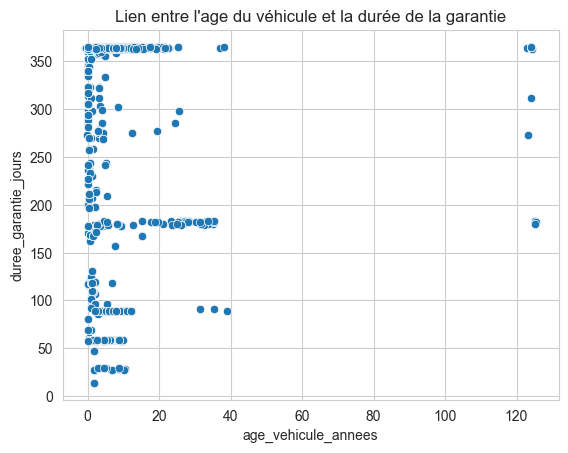

In [21]:
# Question 1: Est-ce que l'age du véhicule détermine (ou influence) la duree de la garantie en jours?
# En d'autres termes, est-ce que les clients qui prennent les garanties les plus longues ont les véhicules les plus vieux

## Visuel 
plt.figure()
sns.scatterplot(data=df, x=df['age_vehicule_annees'], y=df['duree_garantie_jours'])
plt.title("Lien entre l'age du véhicule et la durée de la garantie")

Text(0.5, 1.0, 'Lien entre la puissance du véhicule et la durée de la garantie')

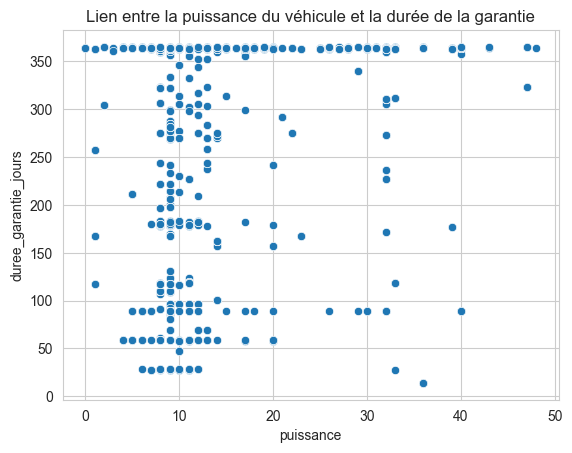

In [22]:
# Question 2: Est-ce que la puissance du véhicule détermine (ou influence) la duree de la garantie en jours?
## Visuel 
plt.figure()
sns.scatterplot(data=df, x=df['puissance'], y=df['duree_garantie_jours'])
plt.title("Lien entre la puissance du véhicule et la durée de la garantie")

Text(0.5, 1.0, 'Lien entre la puissance du véhicule et la durée de la garantie')

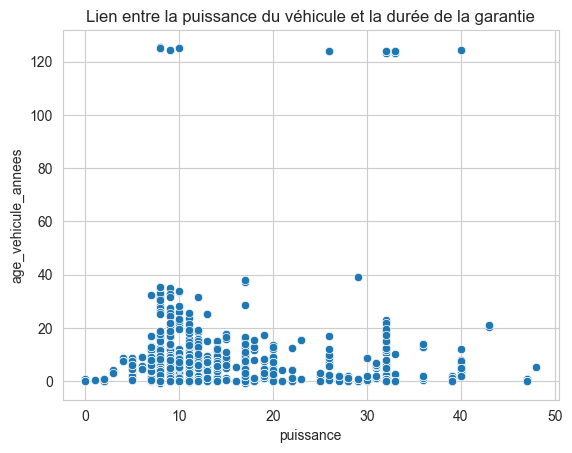

In [23]:
# Question 3: Est-ce que les véhicules les plus puissants assurés sont les plus vieux? (ou inversément)
## Visuel 
plt.figure()
sns.scatterplot(data=df, x=df['puissance'], y=df['age_vehicule_annees'])
plt.title("Lien entre la puissance du véhicule et la durée de la garantie")

<Axes: xlabel='puissance', ylabel='y_cible'>

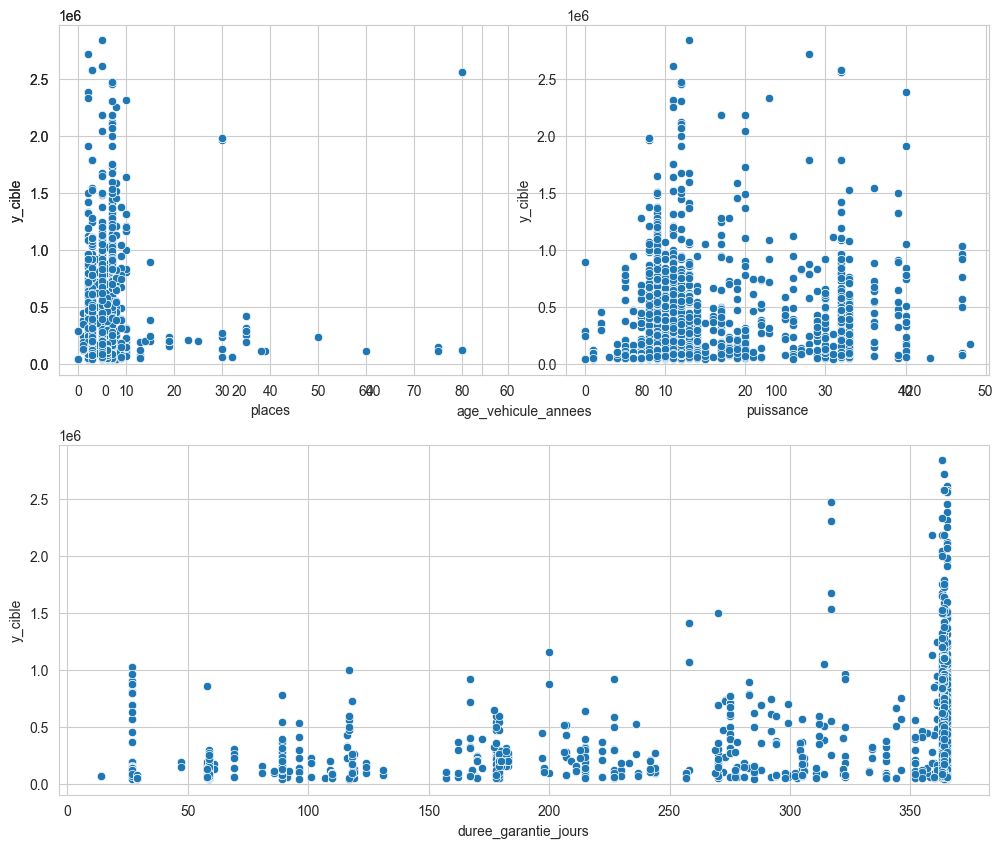

In [24]:
# Question 4: Est ce que la puissance du véhicule, l'age du vehicule, le nombre de places et la durrée de la garantie influence la prime d'assurance?
## Visuel
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
sns.scatterplot(data=df, x=df['age_vehicule_annees'], y=df['y_cible'])
plt.subplot(2, 1, 2)
sns.scatterplot(data=df, x=df['duree_garantie_jours'], y=df['y_cible'])
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x=df['places'], y=df['y_cible'])
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x=df['puissance'], y=df['y_cible'])

<Axes: >

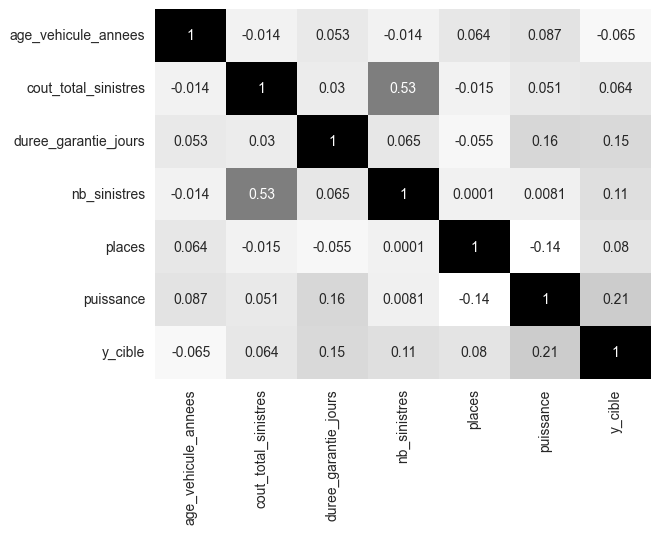

In [25]:
# Matrice de corrélation pour le résumé des corrélations
sns.heatmap(df[quant_cols + ['y_cible']].corr(), annot=True, cmap='Greys', cbar=False)

### 2.2.2 Relations entre les caractéristiques de garantie automobile qualitatives

In [26]:
display(qual_cols)
qual_cols = [col for col in qual_cols if col not in {'Contrat_id', 'marque', 'modèle', 'ville'}]
display(qual_cols)

['categorie_mère',
 'contrat_id',
 'garantie',
 'marque',
 'modèle',
 'segment',
 'type_vehicule',
 'typeinter',
 'typepermis',
 'ville']

['categorie_mère',
 'contrat_id',
 'garantie',
 'segment',
 'type_vehicule',
 'typeinter',
 'typepermis']

In [27]:
# Question: Est-ce qu'il y'a une liaison statistiquement significative entre chaque paire de caractéristique?
## Test de chi2
from scipy.stats import chi2_contingency
from itertools import combinations

def tester_liaisons_qualitatives(df, qual_vars, alpha=0.05):
    df_temp = df.copy()

    resultats = []

    for var1, var2 in combinations(qual_vars, 2):
        # Nettoyage des données pour le couple (suppression des valeurs manquantes)
        data_clean = df_temp[[var1, var2]].dropna()

        # Test du Chi2 de Pearson
        #test_nom = "Chi2 de Pearson"
        contingency_table = pd.crosstab(data_clean[var1], data_clean[var2])
        stat, p_val, _, _ = chi2_contingency(contingency_table)
            
        # Décision statistique
        if np.isnan(p_val):
            decision = "Données insuffisantes"
        elif p_val < alpha:
            decision = f"Lien significatif (p < {alpha})"
        else:
            decision = "Indépendance (Non significatif)"
        
        resultats.append({
            "Couple testé": f"{var1} x {var2}",
            #"Test utilisé": test_nom,
            "Statistique de chi2": stat,
            "p-valeur": p_val,
            "Décision": decision,
        })
    
    # Création du dataframe récapitulatif
    df_res = pd.DataFrame(resultats)

    # Tri par p-valeur croissante
    df_res = df_res.sort_values(by="p-valeur", na_position="last").reset_index(drop=True)

    return df_res


# Application de la fonction
df_tests = tester_liaisons_qualitatives(df=df, qual_vars = qual_cols, alpha=0.05)
df_tests

,Couple testé,Statistique de chi2,p-valeur,Décision
0,categorie_mère x contrat_id,40520.000000,0.000000e+00,Lien significatif (p < 0.05)
1,categorie_mère x garantie,3933.567808,0.000000e+00,Lien significatif (p < 0.05)
2,contrat_id x garantie,38258.115097,0.000000e+00,Lien significatif (p < 0.05)
3,categorie_mère x typepermis,2135.232550,0.000000e+00,Lien significatif (p < 0.05)
4,contrat_id x segment,21322.635234,0.000000e+00,Lien significatif (p < 0.05)
5,contrat_id x typepermis,19351.428196,0.000000e+00,Lien significatif (p < 0.05)
6,contrat_id x typeinter,10130.000000,0.000000e+00,Lien significatif (p < 0.05)
7,contrat_id x type_vehicule,25132.550911,0.000000e+00,Lien significatif (p < 0.05)
8,segment x type_vehicule,12716.055381,0.000000e+00,Lien significatif (p < 0.05)
9,segment x typeinter,1276.657128,4.169831e-268,Lien significatif (p < 0.05)


In [28]:
# Sauvegarde des résultats du test
outputs_path = os.path.join(project_path, 'Outputs')
tests_path = os.path.join(outputs_path, 'Tests statistiques')
tests1_path = os.path.join(tests_path, 'Tests de liaisons qualitatives.xlsx')
df_tests.to_excel(tests1_path, index=False)

### 2.2.3 Relations entre les caractéristiques de garantie automobile qualitatives et quantitatives

In [29]:
display(qual_cols)
display(quant_cols)

['categorie_mère',
 'contrat_id',
 'garantie',
 'segment',
 'type_vehicule',
 'typeinter',
 'typepermis']

['age_vehicule_annees',
 'cout_total_sinistres',
 'duree_garantie_jours',
 'nb_sinistres',
 'places',
 'puissance']

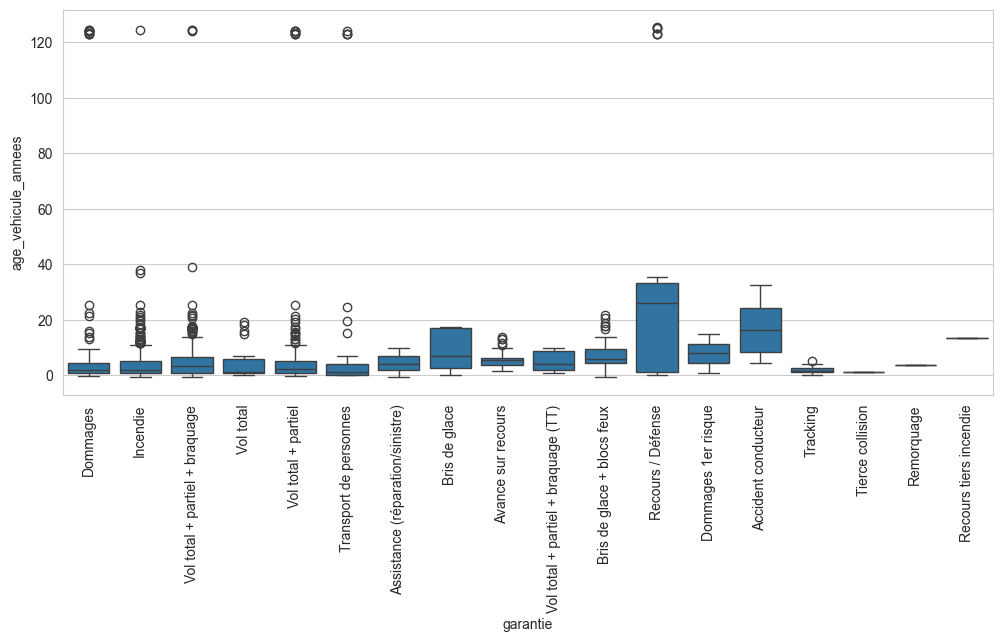

In [30]:
# Visualisation des relations entre les caractéristiques de garantie de type qualitatif et les caractéristiques de garantie de type quantitatif
## Est-ce que le type de garantie dépend de l'age du véhicule?
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x=df['garantie'], y=df['age_vehicule_annees']) 
plt.xticks(rotation=90)
plt.show()

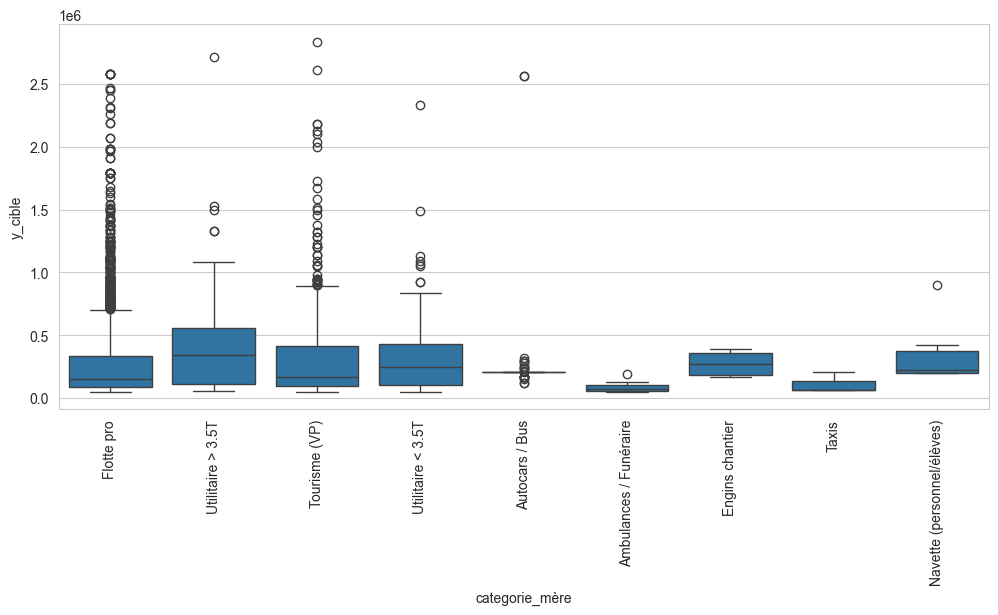

In [31]:
## Est-ce que la prime d'assurance dépends de la catégorie de véhicule
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['categorie_mère'], y=df['y_cible'])
plt.xticks(rotation=90)
plt.show()

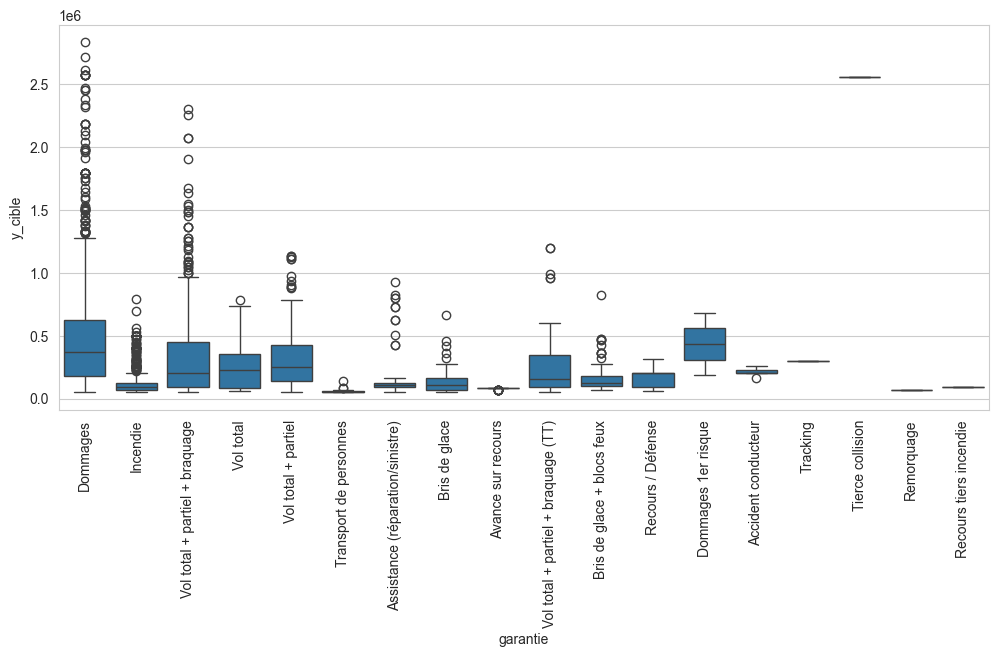

In [32]:
## Est-ce que la prime d'assurance dépends de la catégorie de véhicule
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['garantie'], y=df['y_cible'])
plt.xticks(rotation=90) 
plt.show()

In [33]:
# Checking global (liaisons entre les caractéristiques quantitatives et les caractéristiques qualitatives)
from itertools import product
from scipy.stats import kruskal 
def tester_quanti_vs_quali(df, quanti_vars, nominal_vars, alpha=0.05):
    df_temp = df.copy()

    resultats = []

    # Croisement Quantitative x Nominale (Kruskal-Wallis)
    for var_num, var_nom in product(quanti_vars, nominal_vars):
        data_clean = df_temp[[var_num, var_nom]].dropna()

        # Séparation de la variable selon les groupes de la variable nominale
        groupes = [group[var_num].values for _, group in data_clean.groupby(var_nom)]

        #test_nom = "Kruskal-Wallis"
        stat, p_val = kruskal(*groupes)

        # Décision
        if np.isnan(p_val):
            decision = "Données insuffisantes"
        elif p_val < alpha:
            decision = f"Lien significatif (p < {alpha})"
        else:
            decision = "Indépendance (Non significatif)"
        
        resultats.append({
            "Couple testé": f"{var_num} x {var_nom}",
            #"Test utilisé": test_nom,
            "Statistique de Kruskal-Wallis": stat,
            "p-valeur": p_val,
            "Décision": decision,
        })
    

    # Conversion en Dataframe récapitulatif
    df_res = pd.DataFrame(resultats)

    # Tri par p-valeur croissante
    df_res = df_res.sort_values(by="p-valeur", na_position="last").reset_index(drop=True)
    
    return df_res

# Application de la fonction
df_res = tester_quanti_vs_quali(df=df, quanti_vars=quant_cols + ['y_cible'], nominal_vars=qual_cols)
tests2_path = os.path.join(tests_path, 'Tests relations quanti-quali.xlsx')
df_res.to_excel(tests2_path, index=False)
display(df_res)

,Couple testé,Statistique de Kruskal-Wallis,p-valeur,Décision
0,age_vehicule_annees x contrat_id,4189.566222,0.000000e+00,Lien significatif (p < 0.05)
1,duree_garantie_jours x contrat_id,5058.408826,0.000000e+00,Lien significatif (p < 0.05)
2,places x segment,2110.194453,0.000000e+00,Lien significatif (p < 0.05)
3,places x contrat_id,3811.042243,0.000000e+00,Lien significatif (p < 0.05)
4,puissance x contrat_id,3604.120720,0.000000e+00,Lien significatif (p < 0.05)
5,puissance x segment,2071.921369,0.000000e+00,Lien significatif (p < 0.05)
6,puissance x type_vehicule,2055.515765,0.000000e+00,Lien significatif (p < 0.05)
7,places x type_vehicule,2392.457247,0.000000e+00,Lien significatif (p < 0.05)
8,y_cible x garantie,1424.328615,9.177405e-293,Lien significatif (p < 0.05)
9,age_vehicule_annees x type_vehicule,616.064461,7.985169e-130,Lien significatif (p < 0.05)


## 2.3 Analyse multivariée (Facteur d'inflation de la variance)
L'objectif ici est d'analyser la multicolinéarité dans notre dataset, histoire de savoir si l'information de chaque variable est contenue dans les autres variables. En effet, le **facteur d'inflation de la variance** ou **variance inflation factor (VIF)** nous permet d'analyser la multicolinéarité d'un point de vue multivariée, pour voir pour chaque variable, si elle peut etre expliquée par toutes les autres. Le VIF est donc un scalaire qui peut etre vu comme l'intensité de la multicolinéarité. 

In [34]:
df[quant_cols].dtypes

age_vehicule_annees     float64
cout_total_sinistres    float64
duree_garantie_jours    float64
nb_sinistres            float64
places                  float64
puissance               float64
dtype: object

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Fonction pour calculer le VIF
def calculer_vif_global(df, quanti_vars, quali_vars, threshold=5.0):
    
    # Copie des variables quantitatives et des variables qualitatives
    df_prep = df[quanti_vars + quali_vars].copy()

    # One hot encoding pour les variables nominales avec suppression de la 1ère modalité (drop_first=True)
    df_encoded = pd.get_dummies(df[quali_vars], drop_first=True, dtype=int)
    df_prep = pd.concat([df_prep, df_encoded], axis=1)
    df_prep = df_prep.drop(columns=quali_vars)
    df_prep = df_prep.dropna()

    # Ajout de l'intercept pour statsmodels
    X = df_prep.values
    X_with_const = np.column_stack([np.ones(X.shape[0]), X])

    # Calcul du VIF
    vif_list = []
    feature_names = df_prep.columns

    for i, col in enumerate(feature_names):
        vif_val = variance_inflation_factor(X_with_const, i + 1)

        vif_list.append({
            "Variable / Modalité": col,
            "VIF": round(vif_val, 3),
            "Alerte (>5)": "Fort" if vif_val > threshold else "OK",
        })

    # Dataframe récapitulatif
    df_vif = pd.DataFrame(vif_list)
    return df_vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# Application de la fonction
tableau_vif_global = calculer_vif_global(df, quanti_vars=quant_cols + ['y_cible'], quali_vars=qual_cols)

vif_path = os.path.join(tests_path, 'VIF.xlsx')
tableau_vif_global.to_excel(vif_path, index=False)
display(tableau_vif_global)

c:\Users\DELL\Documents\VEMV\business\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\DELL\Documents\VEMV\business\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


KeyboardInterrupt: 